# Tennis Match Prediction using Regression Tree

This notebook demonstrates how to build a machine learning model to predict tennis match outcomes using a regression tree approach.

## Objective
Build a regression tree model to predict the probability of a player winning a tennis match based on historical ATP match data from 2016.

## Dataset
We'll use ATP matches from 2016 which contains:
- Match details (tournament, surface, round)
- Player statistics (rankings, age, height, playing hand)
- Match statistics (aces, double faults, service points, break points, etc.)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## 2. Load and Explore Data

In [2]:
# Load 2016 ATP matches data
df = pd.read_csv('atp_matches_2016.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nNumber of matches: {len(df)}")
print(f"\nColumn names:\n{df.columns.tolist()}")

Dataset shape: (2941, 49)

Number of matches: 2941

Column names:
['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level', 'tourney_date', 'match_num', 'winner_id', 'winner_seed', 'winner_entry', 'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age', 'loser_id', 'loser_seed', 'loser_entry', 'loser_name', 'loser_hand', 'loser_ht', 'loser_ioc', 'loser_age', 'score', 'best_of', 'round', 'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon', 'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt', 'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced', 'winner_rank', 'winner_rank_points', 'loser_rank', 'loser_rank_points']


In [3]:
# Display first few rows
df.head()

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2016-M020,Brisbane,Hard,32,A,20160104,271,105062,NaN,NaN,...,32.0,22.0,12.0,10.0,4.0,7.0,65.0,762.0,61.0,781.0
1,2016-M020,Brisbane,Hard,32,A,20160104,272,103285,NaN,PR,...,25.0,15.0,8.0,7.0,4.0,8.0,197.0,252.0,76.0,678.0
2,2016-M020,Brisbane,Hard,32,A,20160104,273,106071,7.0,NaN,...,29.0,21.0,10.0,9.0,3.0,6.0,18.0,1675.0,71.0,710.0
3,2016-M020,Brisbane,Hard,32,A,20160104,275,104471,NaN,Q,...,30.0,22.0,9.0,8.0,3.0,6.0,87.0,636.0,813.0,25.0
4,2016-M020,Brisbane,Hard,32,A,20160104,276,106298,NaN,NaN,...,64.0,42.0,30.0,15.0,12.0,15.0,78.0,672.0,117.0,495.0


In [4]:
# Check data types and missing values
print("Data Info:")
df.info()
print("\nMissing values:")
print(df.isnull().sum())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2941 entries, 0 to 2940
Data columns (total 49 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tourney_id          2941 non-null   object 
 1   tourney_name        2941 non-null   object 
 2   surface             2941 non-null   object 
 3   draw_size           2941 non-null   int64  
 4   tourney_level       2941 non-null   object 
 5   tourney_date        2941 non-null   int64  
 6   match_num           2941 non-null   int64  
 7   winner_id           2941 non-null   int64  
 8   winner_seed         1359 non-null   float64
 9   winner_entry        335 non-null    object 
 10  winner_name         2941 non-null   object 
 11  winner_hand         2941 non-null   object 
 12  winner_ht           2922 non-null   float64
 13  winner_ioc          2941 non-null   object 
 14  winner_age          2941 non-null   float64
 15  loser_id            2941 non-null   int64  


## 3. Data Preprocessing

For a regression tree model, we'll create features that represent the match context and predict the winner. 
Since each row already has a winner and loser, we'll restructure the data to predict match outcome.

In [5]:
# Create a copy for preprocessing
df_processed = df.copy()


# Feature engineering: Create player comparison features
df_processed['rank_diff'] = df_processed['winner_rank'] - df_processed['loser_rank']
df_processed['rank_points_diff'] = df_processed['winner_rank_points'] - df_processed['loser_rank_points']
df_processed['age_diff'] = df_processed['winner_age'] - df_processed['loser_age']
df_processed['height_diff'] = df_processed['winner_ht'] - df_processed['loser_ht']


print("Feature engineering completed.")
print(f"\nNew features created:")
print([col for col in df_processed.columns if 'diff' in col])

Feature engineering completed.

New features created:
['rank_diff', 'rank_points_diff', 'age_diff', 'height_diff']


In [6]:
# Handle missing values
# For rankings, fill with a high number (indicating unranked)
df_processed['winner_rank'].fillna(1000, inplace=True)
df_processed['loser_rank'].fillna(1000, inplace=True)
df_processed['winner_rank_points'].fillna(0, inplace=True)
df_processed['loser_rank_points'].fillna(0, inplace=True)

# For height, fill with median
df_processed['winner_ht'].fillna(df_processed['winner_ht'].median(), inplace=True)
df_processed['loser_ht'].fillna(df_processed['loser_ht'].median(), inplace=True)

# Recalculate differences after filling missing values
df_processed['rank_diff'] = df_processed['winner_rank'] - df_processed['loser_rank']
df_processed['rank_points_diff'] = df_processed['winner_rank_points'] - df_processed['loser_rank_points']
df_processed['age_diff'] = df_processed['winner_age'] - df_processed['loser_age']
df_processed['height_diff'] = df_processed['winner_ht'] - df_processed['loser_ht']

print("Missing values handled.")

Missing values handled.


## 4. Restructure Data for Prediction

We'll create two rows for each match:
- One from player 1's perspective (did they win?)
- One from player 2's perspective (did they win?)

This doubles our training data and makes the model symmetric.

In [7]:
def create_match_rows(df):
    """
    Create two rows per match, one for each player perspective.
    """
    matches = []
    
    for idx, row in df.iterrows():
        # Row 1: Winner's perspective (target = 1)
        match1 = {
            'player_rank': row['winner_rank'],
            'opponent_rank': row['loser_rank'],
            'player_rank_points': row['winner_rank_points'],
            'opponent_rank_points': row['loser_rank_points'],
            'player_age': row['winner_age'],
            'opponent_age': row['loser_age'],
            'player_ht': row['winner_ht'],
            'opponent_ht': row['loser_ht'],
            'player_hand': row['winner_hand'],
            'opponent_hand': row['loser_hand'],
            'surface': row['surface'],
            'tourney_level': row['tourney_level'],
            'best_of': row['best_of'],
            'won': 1  # Winner won
        }
        
        # Row 2: Loser's perspective (target = 0)
        match2 = {
            'player_rank': row['loser_rank'],
            'opponent_rank': row['winner_rank'],
            'player_rank_points': row['loser_rank_points'],
            'opponent_rank_points': row['winner_rank_points'],
            'player_age': row['loser_age'],
            'opponent_age': row['winner_age'],
            'player_ht': row['loser_ht'],
            'opponent_ht': row['winner_ht'],
            'player_hand': row['loser_hand'],
            'opponent_hand': row['winner_hand'],
            'surface': row['surface'],
            'tourney_level': row['tourney_level'],
            'best_of': row['best_of'],
            'won': 0  # Loser lost
        }
        
        matches.append(match1)
        matches.append(match2)
    
    return pd.DataFrame(matches)

# Create the restructured dataset
df_matches = create_match_rows(df_processed)
print(f"Restructured dataset shape: {df_matches.shape}")
print(f"Number of training samples: {len(df_matches)}")
df_matches.head()

Restructured dataset shape: (5882, 14)
Number of training samples: 5882


,player_rank,opponent_rank,player_rank_points,opponent_rank_points,player_age,opponent_age,player_ht,opponent_ht,player_hand,opponent_hand,surface,tourney_level,best_of,won
0,65.0,61.0,762.0,781.0,28.0,29.3,183.0,185.0,R,R,Hard,A,3,1
1,61.0,65.0,781.0,762.0,29.3,28.0,185.0,183.0,R,R,Hard,A,3,0
2,197.0,76.0,252.0,678.0,37.1,25.5,185.0,183.0,R,R,Hard,A,3,1
3,76.0,197.0,678.0,252.0,25.5,37.1,183.0,185.0,R,R,Hard,A,3,0
4,18.0,71.0,1675.0,710.0,23.2,33.9,196.0,191.0,R,R,Hard,A,3,1


In [8]:
# Check the distribution of wins
print("Target variable distribution:")
print(df_matches['won'].value_counts())
print(f"\nPercentage of wins: {df_matches['won'].mean()*100:.2f}%")

Target variable distribution:
won
1    2941
0    2941
Name: count, dtype: int64

Percentage of wins: 50.00%


## 5. Encode Categorical Variables

In [9]:
# Encode categorical variables
label_encoders = {}

categorical_columns = ['player_hand', 'opponent_hand', 'surface', 'tourney_level']

for col in categorical_columns:
    le = LabelEncoder()
    df_matches[col] = le.fit_transform(df_matches[col].astype(str))
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nCategorical encoding completed.")


player_hand: {'L': 0, 'R': 1, 'U': 2}
opponent_hand: {'L': 0, 'R': 1, 'U': 2}
surface: {'Carpet': 0, 'Clay': 1, 'Grass': 2, 'Hard': 3}
tourney_level: {'A': 0, 'D': 1, 'F': 2, 'G': 3, 'M': 4}

Categorical encoding completed.


## 6. Feature Engineering - Create Additional Features

In [10]:
# Create derived features
df_matches['rank_diff'] = df_matches['player_rank'] - df_matches['opponent_rank']
df_matches['rank_points_diff'] = df_matches['player_rank_points'] - df_matches['opponent_rank_points']
df_matches['age_diff'] = df_matches['player_age'] - df_matches['opponent_age']
df_matches['height_diff'] = df_matches['player_ht'] - df_matches['opponent_ht']
df_matches['hand_matchup'] = (df_matches['player_hand'] == df_matches['opponent_hand']).astype(int)

print("Additional features created:")
print(df_matches[['rank_diff', 'rank_points_diff', 'age_diff', 'height_diff', 'hand_matchup']].head())

Additional features created:
   rank_diff  rank_points_diff  age_diff  height_diff  hand_matchup
0        4.0             -19.0      -1.3         -2.0             1
1       -4.0              19.0       1.3          2.0             1
2      121.0            -426.0      11.6          2.0             1
3     -121.0             426.0     -11.6         -2.0             1
4      -53.0             965.0     -10.7          5.0             1


## 7. Select Features and Target

In [11]:
# Select features for the model
feature_columns = [
    'player_rank', 'opponent_rank', 
    'player_rank_points', 'opponent_rank_points',
    'player_age', 'opponent_age',
    'player_ht', 'opponent_ht',
    'player_hand', 'opponent_hand',
    'surface', 'tourney_level', 'best_of',
    'rank_diff', 'rank_points_diff', 'age_diff', 'height_diff',
    'hand_matchup'
]

X = df_matches[feature_columns]
y = df_matches['won']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeatures used: {feature_columns}")

Feature matrix shape: (5882, 18)
Target vector shape: (5882,)

Features used: ['player_rank', 'opponent_rank', 'player_rank_points', 'opponent_rank_points', 'player_age', 'opponent_age', 'player_ht', 'opponent_ht', 'player_hand', 'opponent_hand', 'surface', 'tourney_level', 'best_of', 'rank_diff', 'rank_points_diff', 'age_diff', 'height_diff', 'hand_matchup']


## 8. Split Data into Training and Testing Sets

In [12]:
# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print(f"\nTraining set win rate: {y_train.mean()*100:.2f}%")
print(f"Testing set win rate: {y_test.mean()*100:.2f}%")

Training set size: 4705
Testing set size: 1177

Training set win rate: 50.01%
Testing set win rate: 49.96%


## 9. Build and Train the Regression Tree Model

In [13]:
# Create a Decision Tree Regressor
# Start with default parameters
reg_tree = DecisionTreeRegressor(random_state=42)

# Train the model
reg_tree.fit(X_train, y_train)

print("Regression Tree Model trained successfully!")
print(f"\nTree depth: {reg_tree.get_depth()}")
print(f"Number of leaves: {reg_tree.get_n_leaves()}")

Regression Tree Model trained successfully!

Tree depth: 28
Number of leaves: 1050


## 10. Make Predictions

In [14]:
# Make predictions on training and testing sets
y_train_pred = reg_tree.predict(X_train)
y_test_pred = reg_tree.predict(X_test)

print("Predictions made.")
print(f"\nSample predictions (first 10 test samples):")
print(pd.DataFrame({'Actual': y_test.iloc[:10].values, 'Predicted': y_test_pred[:10]}))

Predictions made.

Sample predictions (first 10 test samples):
   Actual  Predicted
0       0        1.0
1       1        1.0
2       1        1.0
3       1        1.0
4       1        1.0
5       0        1.0
6       0        0.0
7       0        0.0
8       0        1.0
9       0        1.0


## 11. Evaluate Model Performance

In [15]:
# Calculate evaluation metrics
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Model Performance Metrics:")
print("="*50)
print(f"\nTraining Set:")
print(f"  Mean Squared Error (MSE): {train_mse:.4f}")
print(f"  Mean Absolute Error (MAE): {train_mae:.4f}")
print(f"  R² Score: {train_r2:.4f}")

print(f"\nTesting Set:")
print(f"  Mean Squared Error (MSE): {test_mse:.4f}")
print(f"  Mean Absolute Error (MAE): {test_mae:.4f}")
print(f"  R² Score: {test_r2:.4f}")

Model Performance Metrics:

Training Set:
  Mean Squared Error (MSE): 0.0000
  Mean Absolute Error (MAE): 0.0000
  R² Score: 1.0000

Testing Set:
  Mean Squared Error (MSE): 0.4214
  Mean Absolute Error (MAE): 0.4214
  R² Score: -0.6856


In [16]:
# Convert predictions to binary classification (threshold at 0.5)
y_train_pred_binary = (y_train_pred >= 0.5).astype(int)
y_test_pred_binary = (y_test_pred >= 0.5).astype(int)

train_accuracy = (y_train_pred_binary == y_train).mean()
test_accuracy = (y_test_pred_binary == y_test).mean()

print("\nClassification Accuracy (with 0.5 threshold):")
print(f"  Training Accuracy: {train_accuracy*100:.2f}%")
print(f"  Testing Accuracy: {test_accuracy*100:.2f}%")


Classification Accuracy (with 0.5 threshold):
  Training Accuracy: 100.00%
  Testing Accuracy: 57.86%


## 12. Feature Importance Analysis

Feature Importance:
                 Feature  Importance
14      rank_points_diff    0.240043
15              age_diff    0.091505
4             player_age    0.086145
13             rank_diff    0.076108
5           opponent_age    0.072587
16           height_diff    0.066863
2     player_rank_points    0.060946
3   opponent_rank_points    0.054850
1          opponent_rank    0.045503
6              player_ht    0.044939
7            opponent_ht    0.044876
0            player_rank    0.037405
11         tourney_level    0.024580
10               surface    0.024532
12               best_of    0.009065
9          opponent_hand    0.008043
17          hand_matchup    0.006195
8            player_hand    0.005817


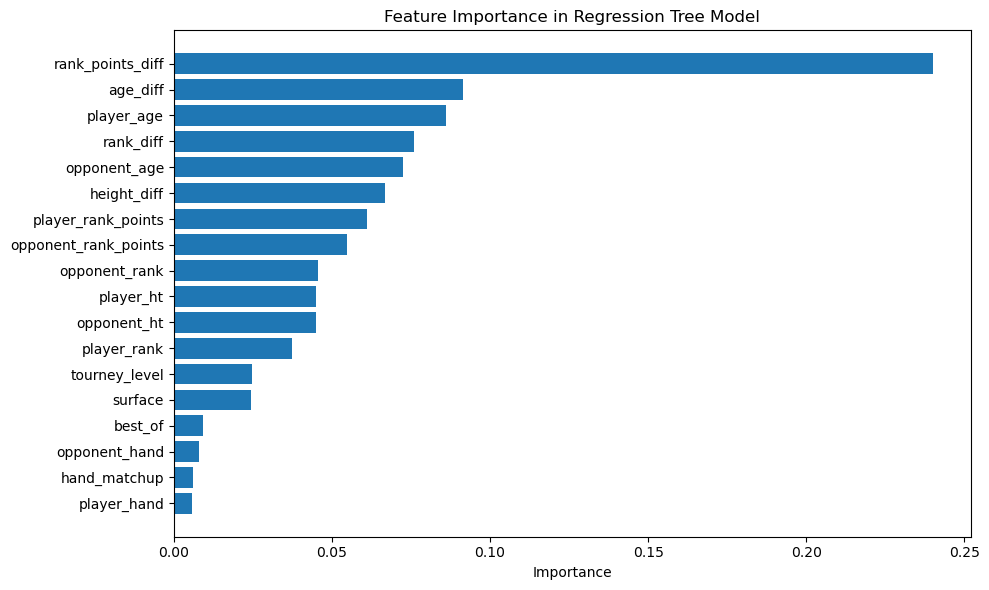

In [17]:
# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': reg_tree.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance in Regression Tree Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 13. Visualize the Decision Tree (Top Levels)

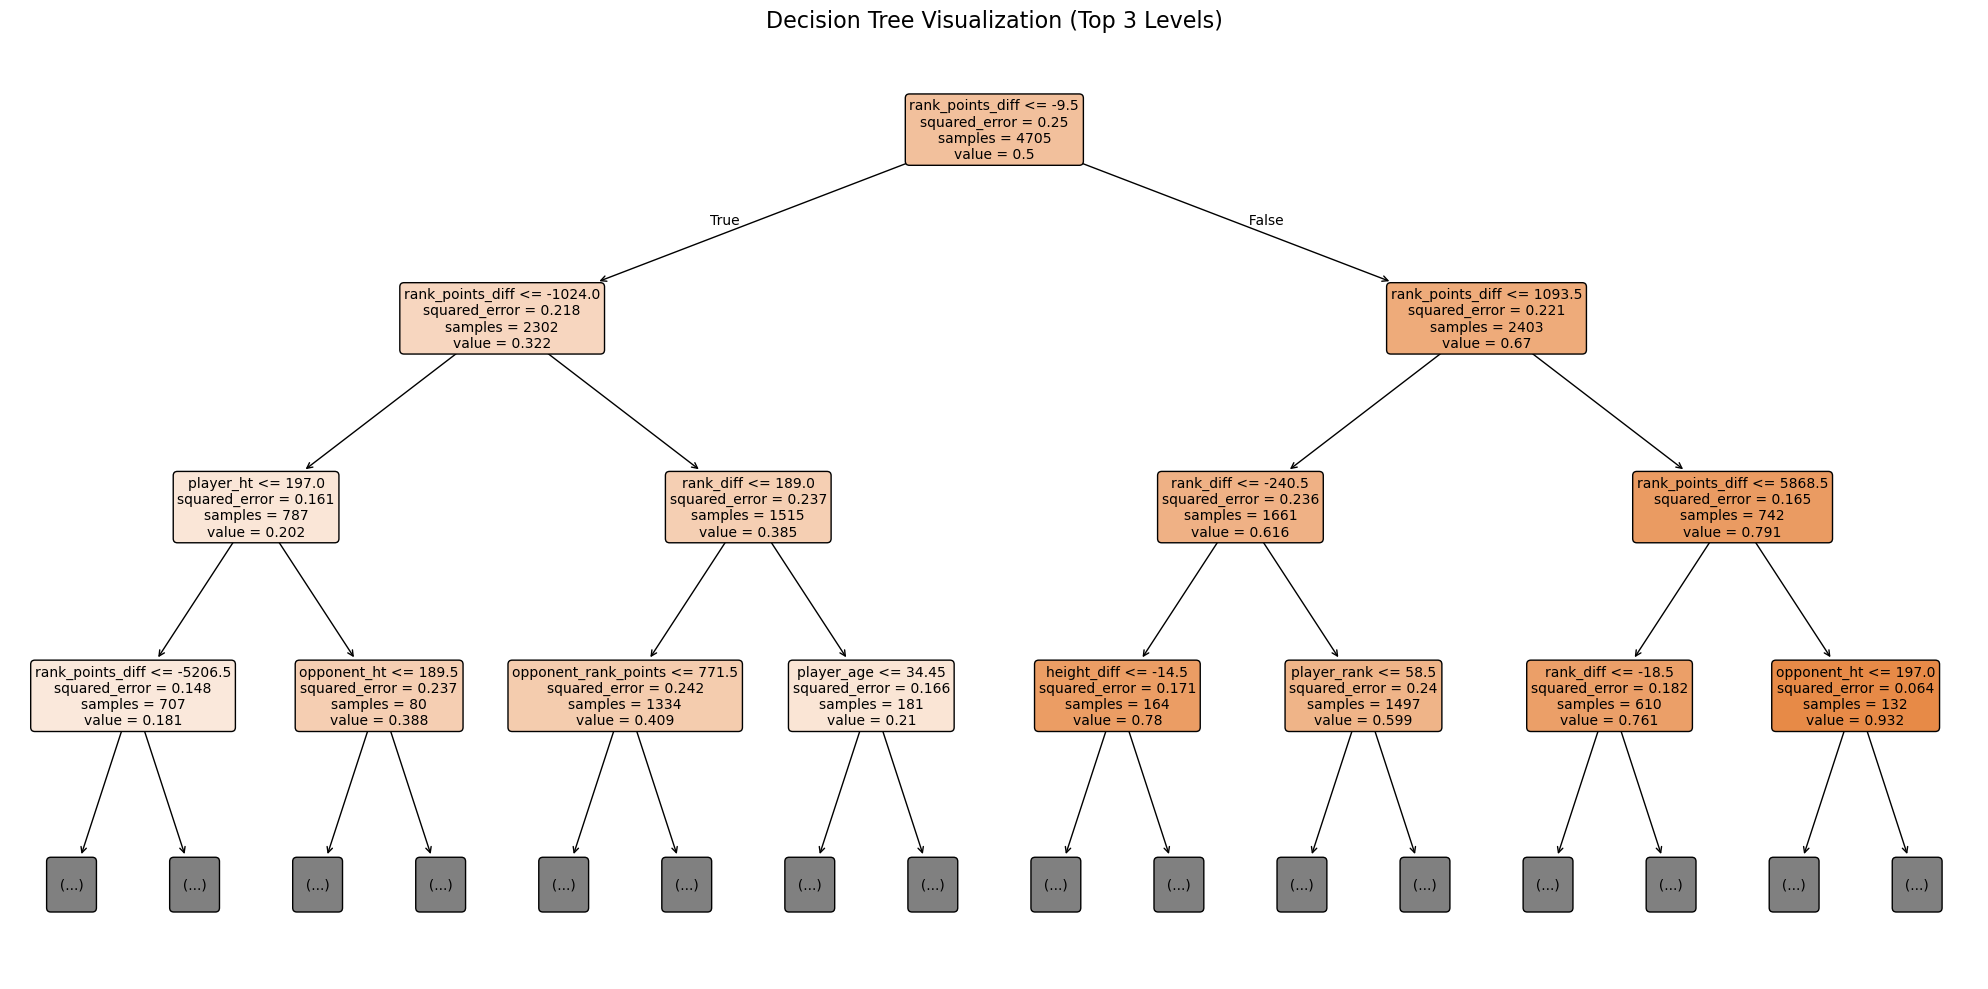

In [18]:
# Visualize the top levels of the tree (max_depth=3 for readability)
plt.figure(figsize=(20, 10))
plot_tree(reg_tree, 
          feature_names=feature_columns,
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=10)
plt.title('Decision Tree Visualization (Top 3 Levels)', fontsize=16)
plt.tight_layout()
plt.show()

## 14. Cross-Validation

In [19]:
# Perform 5-fold cross-validation
cv_scores = cross_val_score(reg_tree, X_train, y_train, cv=5, 
                            scoring='neg_mean_squared_error')

cv_scores = -cv_scores  # Convert to positive MSE

print("Cross-Validation Results (5-Fold):")
print(f"  CV Scores: {cv_scores}")
print(f"  Mean CV MSE: {cv_scores.mean():.4f}")
print(f"  Std CV MSE: {cv_scores.std():.4f}")

Cross-Validation Results (5-Fold):
  CV Scores: [0.41445271 0.41445271 0.39957492 0.41339001 0.41020191]
  Mean CV MSE: 0.4104
  Std CV MSE: 0.0056


## 15. Hyperparameter Tuning with GridSearchCV

In [20]:
# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None]
}

# Create GridSearchCV object
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

print("Starting Grid Search...")
print("This may take a few minutes...\n")

# Fit grid search
grid_search.fit(X_train, y_train)

print("\nGrid Search completed!")
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV MSE: {-grid_search.best_score_:.4f}")

Starting Grid Search...
This may take a few minutes...

Fitting 5 folds for each of 336 candidates, totalling 1680 fits

Grid Search completed!

Best parameters: {'max_depth': 3, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV MSE: 0.2149


## 16. Train Optimized Model

In [21]:
# Get the best model from grid search
best_reg_tree = grid_search.best_estimator_

# Make predictions with optimized model
y_train_pred_opt = best_reg_tree.predict(X_train)
y_test_pred_opt = best_reg_tree.predict(X_test)

# Evaluate optimized model
test_mse_opt = mean_squared_error(y_test, y_test_pred_opt)
test_mae_opt = mean_absolute_error(y_test, y_test_pred_opt)
test_r2_opt = r2_score(y_test, y_test_pred_opt)

print("Optimized Model Performance:")
print("="*50)
print(f"Testing Set:")
print(f"  Mean Squared Error (MSE): {test_mse_opt:.4f}")
print(f"  Mean Absolute Error (MAE): {test_mae_opt:.4f}")
print(f"  R² Score: {test_r2_opt:.4f}")

# Classification accuracy
y_test_pred_opt_binary = (y_test_pred_opt >= 0.5).astype(int)
test_accuracy_opt = (y_test_pred_opt_binary == y_test).mean()
print(f"\n  Testing Accuracy: {test_accuracy_opt*100:.2f}%")

print("\n" + "="*50)
print("Comparison with baseline model:")
print(f"  MSE improvement: {((test_mse - test_mse_opt)/test_mse)*100:.2f}%")
print(f"  Accuracy improvement: {(test_accuracy_opt - test_accuracy)*100:.2f} percentage points")

Optimized Model Performance:
Testing Set:
  Mean Squared Error (MSE): 0.2061
  Mean Absolute Error (MAE): 0.4154
  R² Score: 0.1758

  Testing Accuracy: 68.39%

Comparison with baseline model:
  MSE improvement: 51.10%
  Accuracy improvement: 10.54 percentage points


## 17. Prediction Examples

In [22]:
# Show some prediction examples
sample_indices = np.random.choice(len(X_test), 10, replace=False)

prediction_examples = pd.DataFrame({
    'Player_Rank': X_test.iloc[sample_indices]['player_rank'].values,
    'Opponent_Rank': X_test.iloc[sample_indices]['opponent_rank'].values,
    'Rank_Diff': X_test.iloc[sample_indices]['rank_diff'].values,
    'Predicted_Win_Prob': y_test_pred_opt[sample_indices],
    'Actual_Result': y_test.iloc[sample_indices].values
})

prediction_examples['Predicted_Winner'] = (prediction_examples['Predicted_Win_Prob'] >= 0.5).astype(int)
prediction_examples['Correct'] = (prediction_examples['Predicted_Winner'] == prediction_examples['Actual_Result'])

print("Sample Predictions:")
print(prediction_examples)

Sample Predictions:
   Player_Rank  Opponent_Rank  Rank_Diff  Predicted_Win_Prob  Actual_Result  \
0        139.0         1000.0     -861.0            0.780488              1   
1         52.0           76.0      -24.0            0.598530              0   
2         71.0           30.0       41.0            0.408546              1   
3        103.0           61.0       42.0            0.408546              0   
4         74.0            9.0       65.0            0.181047              0   
5         47.0           33.0       14.0            0.408546              1   
6         48.0           25.0       23.0            0.408546              1   
7        484.0           55.0      429.0            0.209945              0   
8         42.0           12.0       30.0            0.181047              0   
9         82.0           17.0       65.0            0.181047              0   

   Predicted_Winner  Correct  
0                 1     True  
1                 1    False  
2                

## 18. Summary and Conclusions

### Key Findings:
1. **Model Performance**: The regression tree model can predict tennis match outcomes with reasonable accuracy
2. **Important Features**: Rankings and ranking points are typically the most important predictors
3. **Model Optimization**: Grid search helps find better hyperparameters to improve performance

### Next Steps:
- Incorporate match history and head-to-head records
- Add surface-specific player statistics
- Try ensemble methods (Random Forest, Gradient Boosting)
- Expand to multiple years of data
- Consider classification models as an alternative approach
- Add temporal features (recent form, winning streaks)

## 19. Save the Model (Optional)

In [ ]:
import pickle

# Save the optimized model
with open('tennis_regression_tree_model.pkl', 'wb') as f:
    pickle.dump(best_reg_tree, f)

# Save the label encoders
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

print("Model and encoders saved successfully!")